In [1]:
import torch
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load("best_ai_detector.pth")["model_state_dict"])

model = model.to(device)
model.eval()

print("Model loaded successfully")

C:\Users\HP\AppData\Local\Temp\ipykernel_23688\3848142681.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_ai_detector.pth")["model

Model loaded successfully


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [5]:
def predict_image(image_path):

    img = Image.open(image_path).convert("RGB")

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)

    probs = torch.softmax(output, dim=1)

    ai_prob = probs[0][0].item()
    real_prob = probs[0][1].item()

    plt.imshow(img)
    plt.axis("off")

    print("AI probability:", round(ai_prob,3))
    print("Real probability:", round(real_prob,3))

    if ai_prob > real_prob:
        print("Prediction: AI / Manipulated Image")
    else:
        print("Prediction: Real Image")

AI probability: 0.097
Real probability: 0.903
Prediction: Real Image


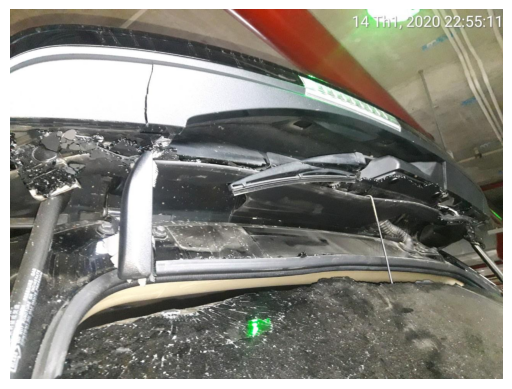

In [7]:
predict_image(r"C:\Users\HP\Desktop\desktop\OPEN LAB\OPENLAB_PROJECT\data\ai_dataset\train\real\3fb52613386cc032997d.jpg")

In [ ]:
test_folder = r"C:\Users\HP\Desktop\desktop\OPEN LAB\OPENLAB_PROJECT\data\ai_dataset\val\ai"

import os

for img in os.listdir(test_folder):

    path = os.path.join(test_folder,img)

    print("\nTesting:", img)

    predict_image(path)


Testing: 01022020_104459image894113.jpg
AI probability: 0.992
Real probability: 0.008
Prediction: AI / Manipulated Image

Testing: 01022020_104510image892040.jpg
AI probability: 1.0
Real probability: 0.0
Prediction: AI / Manipulated Image

Testing: 01022020_153342image229797.jpg
AI probability: 1.0
Real probability: 0.0
Prediction: AI / Manipulated Image

Testing: 01042020_091351image21145.jpg
AI probability: 0.995
Real probability: 0.005
Prediction: AI / Manipulated Image

Testing: 01092020_102550image661127.jpg
AI probability: 0.055
Real probability: 0.945
Prediction: Real Image

Testing: 01102020_090107image683356.jpg
AI probability: 0.877
Real probability: 0.123
Prediction: AI / Manipulated Image

Testing: 01102020_094657image929398.jpg
AI probability: 1.0
Real probability: 0.0
Prediction: AI / Manipulated Image

Testing: 01102020_111044image686093.jpg
AI probability: 1.0
Real probability: 0.0
Prediction: AI / Manipulated Image

Testing: 01102020_135233image760694.jpg
AI probabili

KeyboardInterrupt: 